# Imports and data

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array
import matplotlib.pyplot as plt

# Bianchi period:
start_date = '1971-08-31'
end_date = '2018-12-31'

# end_date = '2025-06-30' # kr and gsw end date
maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# Apply the shared per-series publication lag policy to latest-snapshot macro data
fred_md = bu.apply_fred_md_publication_lag(fred_md_raw)  

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Backfill fred_md to avoid nans
fred_md = fred_md.bfill()

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
groups = groups_as_array(X, level='group')

y_all = xr[['24','36','48','60','72','84','96','108','120']].values
dates = xr.index

# Expanding window estimation

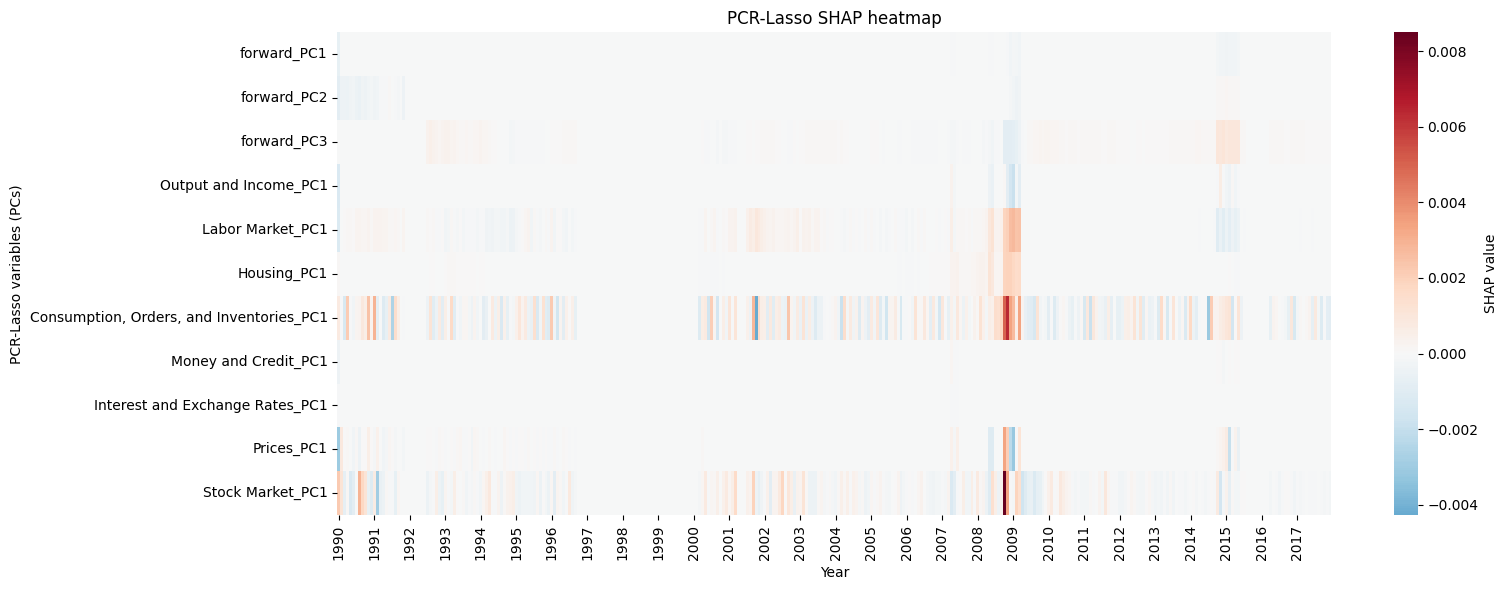

In [ ]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt, shap
from utils.persistence_utils import iter_snapshot_models

run_name = "pcamg_100seeds_monthly"   # one seed/run is fine

def to_pc_space(model, Xs):
    # yields/forward -> PCA
    ys = Xs[model.series]
    ys_pc = model.pca.transform(model.scaler_series.transform(ys))
    names = [f"{model.series}_PC{i+1}" for i in range(ys_pc.shape[1])]

    # fred grouped categories -> per-group PCA(s)
    fred = Xs["fred"]
    fred_s = pd.DataFrame(model.scaler_fred.transform(fred), index=fred.index, columns=fred.columns)
    macro_blocks, macro_names = [], []
    for cat, pca in model.fred_pcas.items():
        sc = pca.transform(fred_s[cat])             # shape (n, macro_pcs)
        macro_blocks.append(sc)
        macro_names += [f"{cat}_PC{j+1}" for j in range(sc.shape[1])]

    F = np.concatenate([ys_pc, np.hstack(macro_blocks)], axis=1)
    Z = model.scaler_features.transform(F)          # final linear-model feature space
    return Z, names + macro_names

rows = []
for rec, model in iter_snapshot_models(run_name=run_name, seeds=[0]):  # one run/seed
    t = int(rec["t_index"])
    if t < 2:
        continue
    X_bg = X.iloc[max(0, t-128):t]      # background window
    X_ex = X.iloc[[t]]                  # explain one date

    Z_bg, feat_names = to_pc_space(model, X_bg)
    Z_ex, _ = to_pc_space(model, X_ex)

    explainer = shap.LinearExplainer(model.model, Z_bg)
    sv = explainer.shap_values(Z_ex)

    # make shape handling robust across SHAP versions
    if isinstance(sv, list):                 # old SHAP multi-output format
        sv = np.stack(sv, axis=-1)           # (n_samples, n_features, n_outputs)
    sv = np.asarray(sv)

    target_i = 0  # choose output index (e.g., 0='24m', ..., 8='120m')

    if sv.ndim == 3:                         # multi-output
        vals = sv[0, :, target_i]
    elif sv.ndim == 2:                       # single-output
        vals = sv[0]
    else:
        vals = sv.reshape(-1)

    for nm, v in zip(feat_names, vals):
        rows.append({"date": pd.to_datetime(rec["date"]), "feature": nm, "shap": float(v)})

shap_df = pd.DataFrame(rows)

# heatmap: y=PC variables (PCR-Lasso categories), x=date, value=SHAP
y_order = [
    "forward_PC1", "forward_PC2", "forward_PC3",
    "Output and Income_PC1",
    "Labor Market_PC1",
    "Housing_PC1",
    "Consumption, Orders, and Inventories_PC1",
    "Money and Credit_PC1",
    "Interest and Exchange Rates_PC1",
    "Prices_PC1",
    "Stock Market_PC1",
]

H = (shap_df
     .pivot_table(index="feature", columns="date", values="shap", aggfunc="mean")
     .fillna(0.0))

# Apply y-order safely (keeps only features that exist)
H = H.reindex([f for f in y_order if f in H.index])

plt.figure(figsize=(16, max(6, 0.35 * len(H))))
ax = sns.heatmap(H, cmap="RdBu_r", center=0, cbar_kws={"label": "SHAP value"})

# X-axis: show only year labels (one tick per year, assuming monthly columns)
cols = H.columns
year_starts = np.where(cols.to_series().dt.year.ne(cols.to_series().dt.year.shift()))[0]
ax.set_xticks(year_starts + 0.5)
ax.set_xticklabels(cols[year_starts].year.astype(str), rotation=90)

plt.xlabel("Year")
plt.ylabel("PCR-Lasso variables (PCs)")
plt.title("PCR-Lasso SHAP heatmap")
plt.tight_layout()
plt.show()